In [ ]:
from pathlib import Path
import sys
parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import plotting.plotting_style as plt
from plotting.plotting_style import rgb
import util
import numpy as np
import pandas as pd

In [9]:
df = util.load_data()
df['altersklasse'].value_counts()   

altersklasse
20         41866
18         40927
U23        30382
Maenner    24293
Frauen     24061
Name: count, dtype: int64

In [10]:
df = df[df['altersklasse'].isin(['Maenner', 'Frauen', 'U23'])]
df['geschlecht'].value_counts()

geschlecht
M    39715
W    39021
Name: count, dtype: int64

In [11]:
df_wind = df[df['wind'].notna()].copy()
print(df_wind['altersklasse'].value_counts())
print(df_wind['disziplin'].value_counts())

df_wind = df_wind[df_wind['altersklasse'].isin(['Maenner', 'Frauen', ])]

altersklasse
U23        7246
Frauen     5402
Maenner    5398
Name: count, dtype: int64
disziplin
100 m            3760
Weitsprung       3622
200 m            3597
Dreisprung       3541
100 m Huerden    1780
110 m Huerden    1746
Name: count, dtype: int64


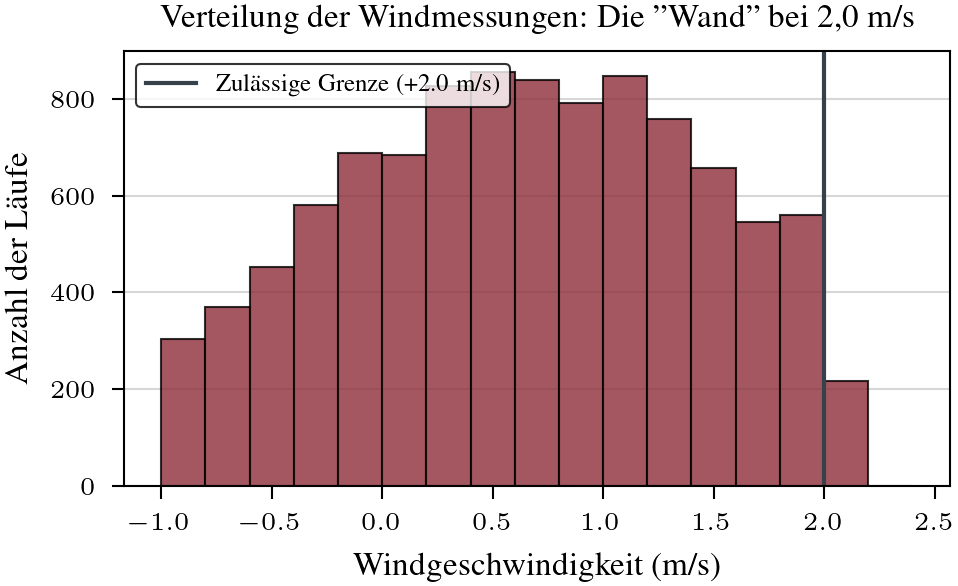

In [12]:
# Größe des Plots festlegen
plt.figure()

# Histogramm erstellen
# bins=15 sorgt für eine gute Unterteilung der Balken
# alpha=0.7 macht die Balken leicht transparent
# edgecolor='black' macht schwarze Ränder um die Balken (sieht sauberer aus)
plt.hist(df_wind['wind'], bins=np.arange(-1, 2.5, 0.2), edgecolor='black', alpha=0.8)

# Eine rote Linie bei +2.0 m/s ziehen (die "illegale" Grenze)
plt.axvline(x=2.0, color=rgb.tue_dark, linestyle='-', label='Zulässige Grenze (+2.0 m/s)')

# Beschriftungen (Wichtig für Data Literacy!)
plt.title('Verteilung der Windmessungen: Die "Wand" bei 2,0 m/s')
plt.xlabel('Windgeschwindigkeit (m/s)')
plt.ylabel('Anzahl der Läufe')
plt.legend()
plt.grid(axis='y', alpha=0.5)

# Anzeigen
plt.show()

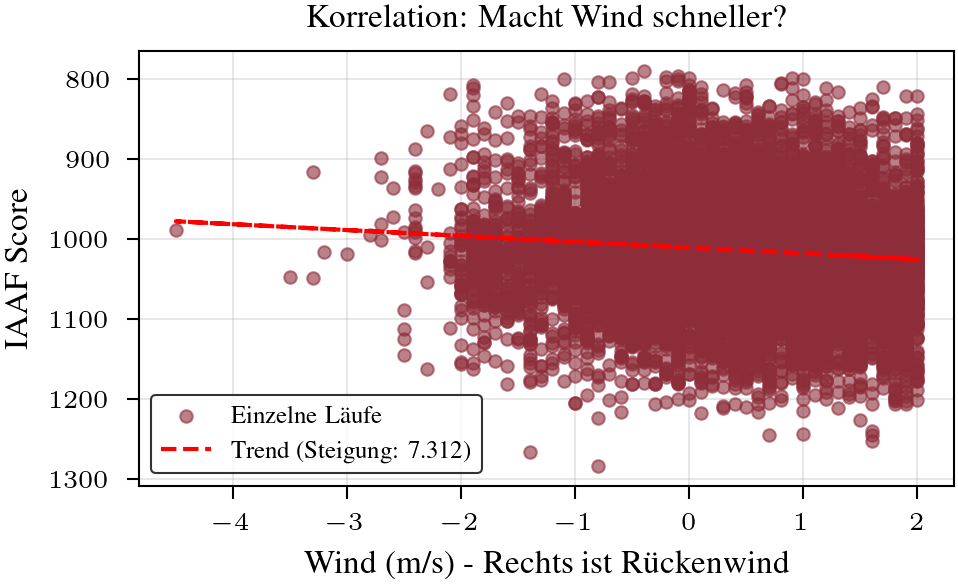

In [13]:
# Scatterplot: X=Wind, Y=Leistung
plt.scatter(df_wind['wind'], df_wind['iaaf_score'], alpha=0.6, label='Einzelne Läufe', marker='.')

# --- Trendlinie hinzufügen (Mathematischer Beweis) ---
# Wir nutzen numpy (polyfit), um eine Gerade durch die Punktewolke zu legen
# 1 bedeutet: Polynom 1. Grades (eine Gerade)
steigung, achsenabschnitt = np.polyfit(df_wind['wind'], df_wind['iaaf_score'], 1)
trendlinie = np.poly1d((steigung, achsenabschnitt))

# Die Linie plotten
plt.plot(df_wind['wind'], trendlinie(df_wind['wind']), "r--", label=f'Trend (Steigung: {steigung:.3f})')

# Beschriftungen
plt.title('Korrelation: Macht Wind schneller?')
plt.xlabel('Wind (m/s) - Rechts ist Rückenwind')
plt.ylabel('IAAF Score')

# WICHTIG: Y-Achse umdrehen! Im Sprint ist eine "niedrigere" Zeit besser ("höher" im Ranking).
# Wenn wir die Achse umdrehen, sieht es intuitiver aus (Besser = Oben).
plt.gca().invert_yaxis()

plt.legend()
plt.grid(True, alpha=0.3)

# # Textbox mit Erklärung ins Bild packen
# plt.text(0.5, 11.0, f"Je steiler die rote Linie,\ndesto stärker der Windeinfluss.", 
#          bbox=dict(facecolor='white', alpha=0.8))

plt.show()

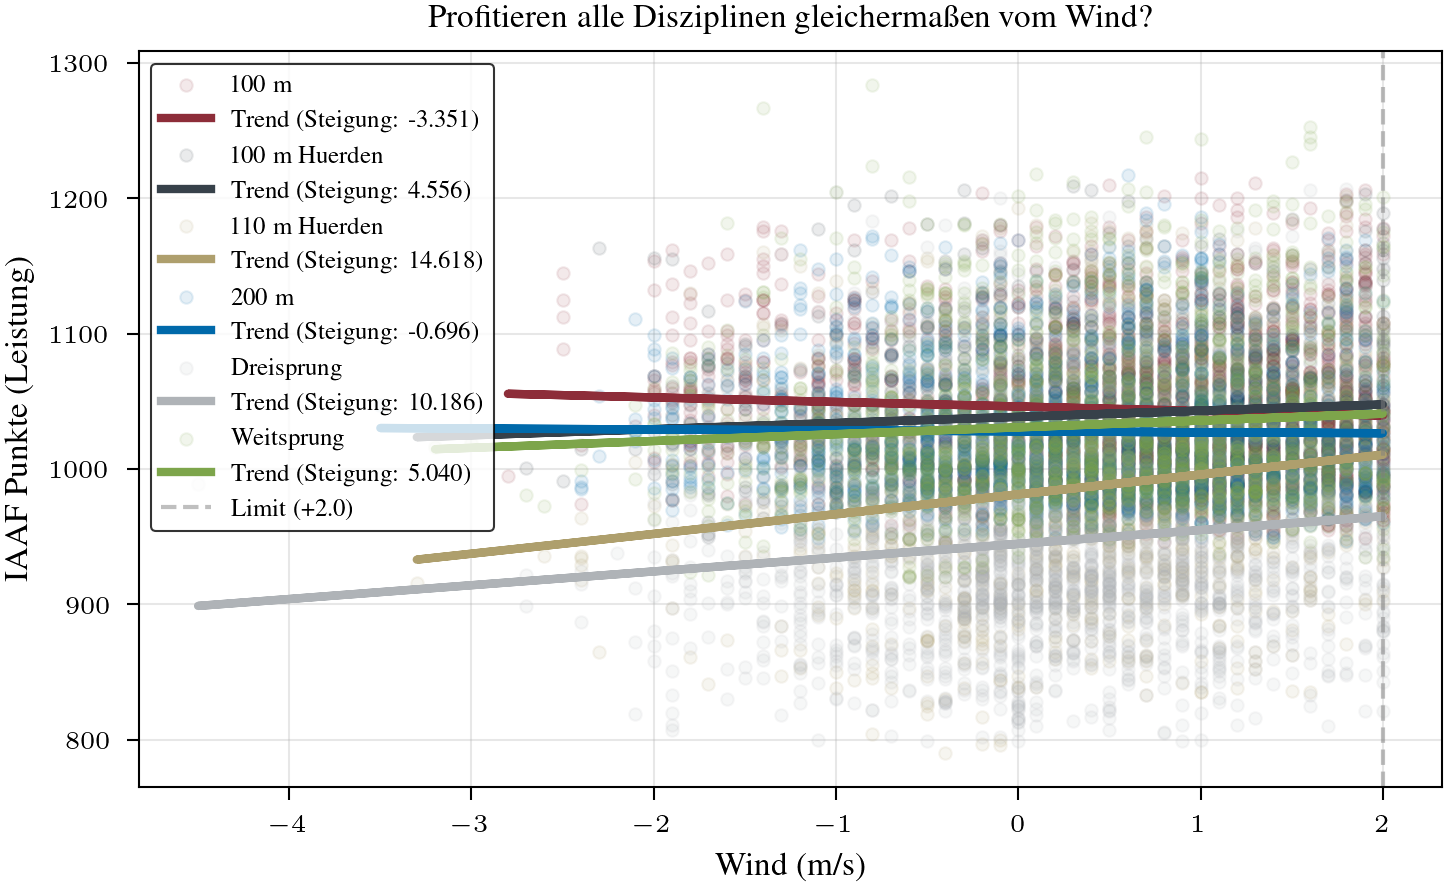

In [14]:

# Wir gruppieren nach Disziplin, damit jede eine andere Farbe bekommt
groups = df_wind.groupby('disziplin')

with plt.rc_context(plt.increase_figsize(1.5)):
    for name, group in groups:
        plt.scatter(group['wind'], group['iaaf_score'], label=name, alpha=0.1, marker='.')
        steigung, achsenabschnitt = np.polyfit(group['wind'], group['iaaf_score'], 1)
        trendlinie = np.poly1d((steigung, achsenabschnitt))

        # Die Linie plotten
        plt.plot(group['wind'], trendlinie(group['wind']), linewidth=2, label=f'Trend (Steigung: {steigung:.3f})')
    plt.axvline(x=2.0, color='gray', linestyle='--', alpha=0.5, label='Limit (+2.0)')

    plt.title('Profitieren alle Disziplinen gleichermaßen vom Wind?')
    plt.xlabel('Wind (m/s)')
    plt.ylabel('IAAF Punkte (Leistung)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [15]:
heatmap_data = df.groupby(['disziplin', 'jahr'])['iaaf_score'].mean().unstack()
with plt.rc_context(plt.increase_figsze(1.5)):

    # Matplotlibs imshow nutzen
    im = plt.imshow(heatmap_data, cmap='RdYlGn', aspect='auto') 
    # 'RdYlGn' = Red-Yellow-Green (Grün = hohe Punktzahl/gut)

    # Achsenbeschriftungen setzen
    plt.colorbar(im, label='Durchschnittliche IAAF Punkte')
    plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns, rotation=45)
    plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)

    plt.title('Heatmap: Stärken und Schwächen über die Zeit', fontsize=14)
    plt.xlabel('Jahr')
    plt.ylabel('Disziplin')
    # plt.tight_layout()
    plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'increase_figsze'

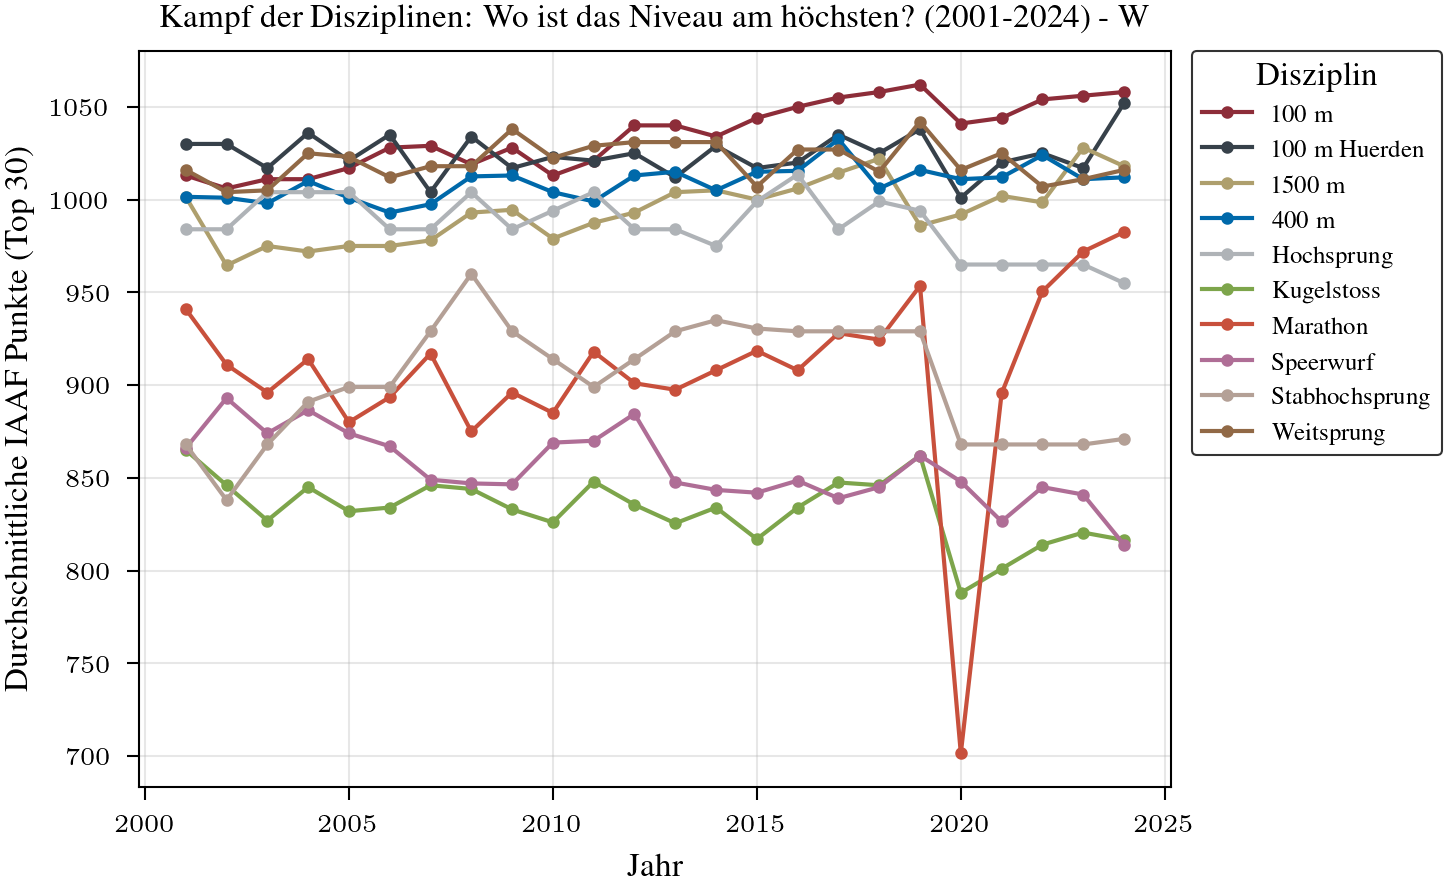

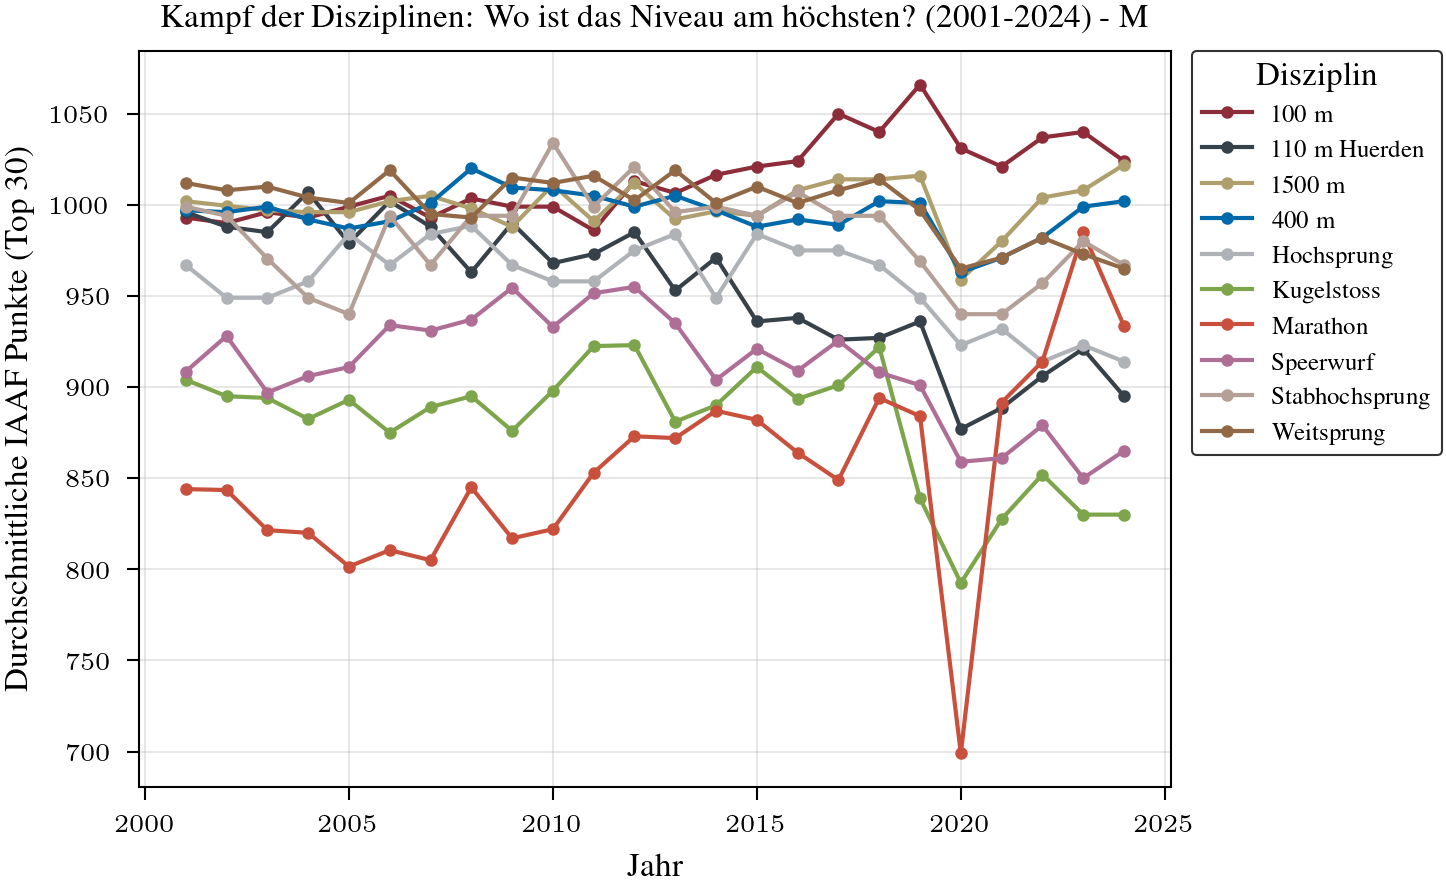

In [ ]:
selected_disciplines = [
    '100 m', '400 m', '1500 m', 'Marathon', 
    '100 m Huerden', '110 m Huerden', 'Hochsprung', 'Weitsprung', 
    'Stabhochsprung', 'Speerwurf', 'Kugelstoss'
]

# Filtern des DataFrames auf diese Disziplinen
df_filtered = df[df['disziplin'].isin(selected_disciplines)]

gender = df_filtered['geschlecht'].unique()

for g in gender:
    df_filtered_gender = df_filtered[df_filtered['geschlecht'] == g]
    # Aggregieren: Durchschnitts-Score pro Jahr und Disziplin
    # Wir nutzen .unstack(), um die Disziplinen in Spalten zu bekommen (perfekt fürs Plotten)
    trend_data = df_filtered_gender.groupby(['jahr', 'disziplin'])['iaaf_score'].median().unstack()

    with plt.rc_context(plt.increase_figsze(1.5)):

        # Wir definieren eine Farbliste (Colormap), damit man 10 Farben gut unterscheiden kann
        # 'tab10' ist eine Standard-Palette mit 10 kräftigen Farben
        # colors = plt.cm.tab10(np.linspace(0, 1, len(selected_disciplines)))

        # Schleife durch jede Disziplin, um sie zu plotten
        for i, disziplin in enumerate(trend_data.columns):
            plt.plot(trend_data.index, 
                    trend_data[disziplin], 
                    marker='o', 
                    markersize=2, 
                    linewidth=1, 
                    label=disziplin)

        # Styling
        plt.title(f'Kampf der Disziplinen: Wo ist das Niveau am höchsten? (2001-2024) - {g}')
        plt.xlabel('Jahr')
        plt.ylabel('Durchschnittliche IAAF Punkte (Top 30)')
        plt.grid(True, alpha=0.3)

        # Legende nach außen schieben, damit sie nicht die Linien verdeckt
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Disziplin")

        plt.show()

In [ ]:
df['disziplin'].unique()

array(['100 m', '200 m', '400 m', '800 m', '1500 m', '3000 m', '5000 m',
       '10 000 m', '10 km', 'Halbmarathon', 'Marathon', '100 km',
       '100 m Huerden', '400 m Huerden', '3000 m Hindernis', 'Hochsprung',
       'Stabhochsprung', 'Weitsprung', 'Dreisprung', 'Kugelstoss',
       'Diskuswurf', 'Hammerwurf', 'Speerwurf', 'Siebenkampf', '1000 m',
       '110 m Huerden', '10 000 m Gehen', '50 km Gehen', 'Zehnkampf',
       '5 km'], dtype=object)

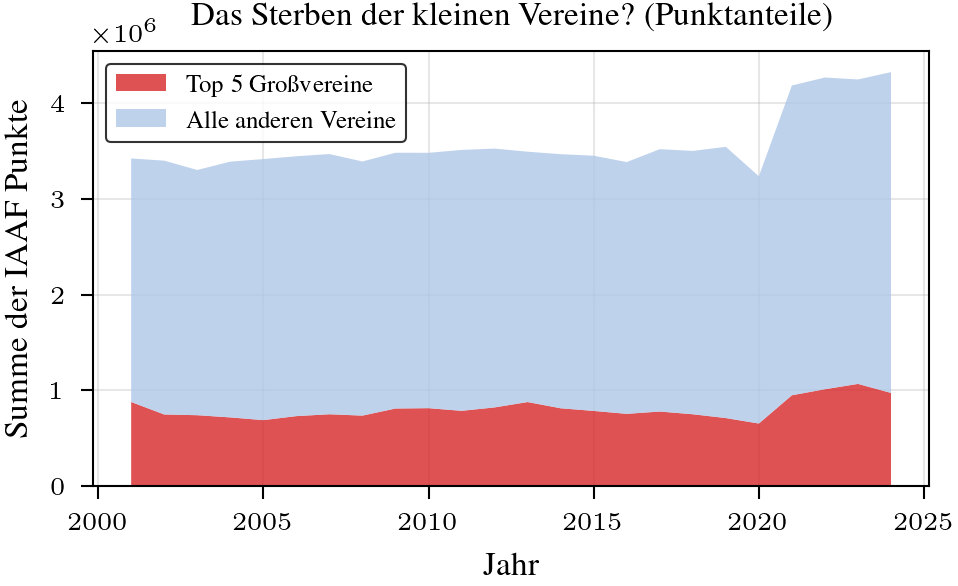

In [ ]:
dominance_data = []
years = np.arange(2001, 2025)
for y in years:
    df_year = df[df['jahr'] == y]
    total_points = df_year['iaaf_score'].sum()
    
    # Punkte pro Verein summieren und sortieren
    club_points = df_year.groupby('verein')['iaaf_score'].sum().sort_values(ascending=False)
    
    top5_points = club_points.iloc[:10].sum()
    rest_points = total_points - top5_points
    
    dominance_data.append([y, top5_points, rest_points])

df_dom = pd.DataFrame(dominance_data, columns=['jahr', 'Top 5 Vereine', 'Restliche Vereine'])

# Plotten
plt.stackplot(df_dom['jahr'], 
              df_dom['Top 5 Vereine'], 
              df_dom['Restliche Vereine'], 
              labels=['Top 5 Großvereine', 'Alle anderen Vereine'],
              colors=['#d62728', '#aec7e8'], alpha=0.8)

plt.title('Das Sterben der kleinen Vereine? (Punktanteile)')
plt.xlabel('Jahr')
plt.ylabel('Summe der IAAF Punkte')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

jahr
2001    551
2002    606
2003    600
2004    585
2005    612
2006    596
2007    625
2008    600
2009    613
2010    617
2011    593
2012    608
2013    585
2014    580
2015    579
2016    583
2017    586
2018    682
2019    644
2020    697
2021    610
2022    634
2023    616
2024    651
Name: verein, dtype: int64


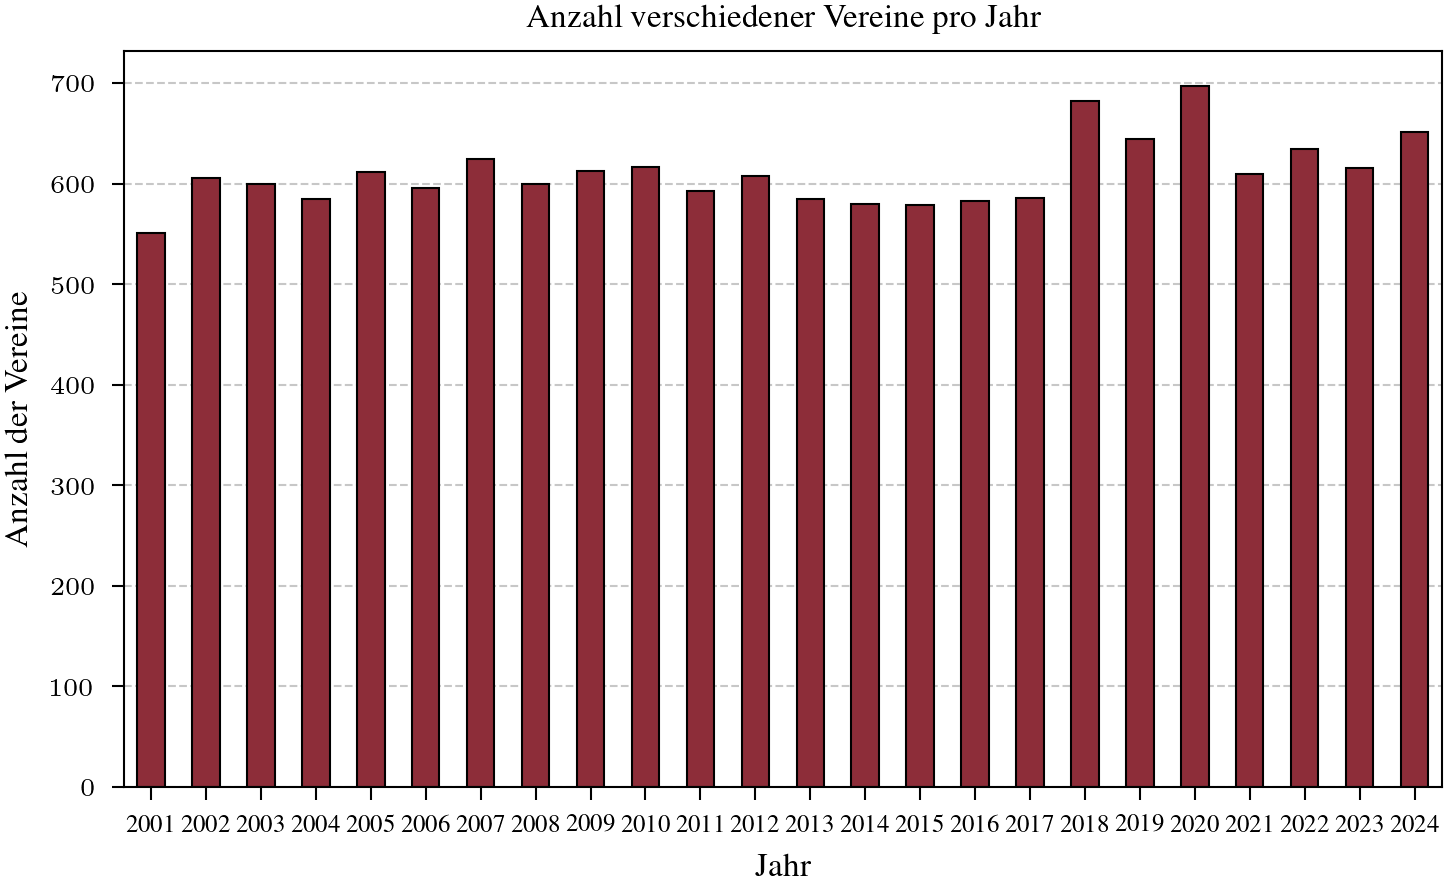

In [ ]:
vereine_pro_jahr = df.groupby('jahr')['verein'].nunique()
with plt.rc_context(plt.increase_figsze(1.5)):
    # (Optional) Ergebnis anzeigen
    print(vereine_pro_jahr)

    # 3. Plotten
    # plt.figure(figsize=(10, 6))
    vereine_pro_jahr.plot(kind='bar', edgecolor='black')

    plt.title('Anzahl verschiedener Vereine pro Jahr')
    plt.xlabel('Jahr')
    plt.ylabel('Anzahl der Vereine')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=0) # Damit die Jahreszahlen gerade stehen

    # plt.tight_layout()
    plt.show()

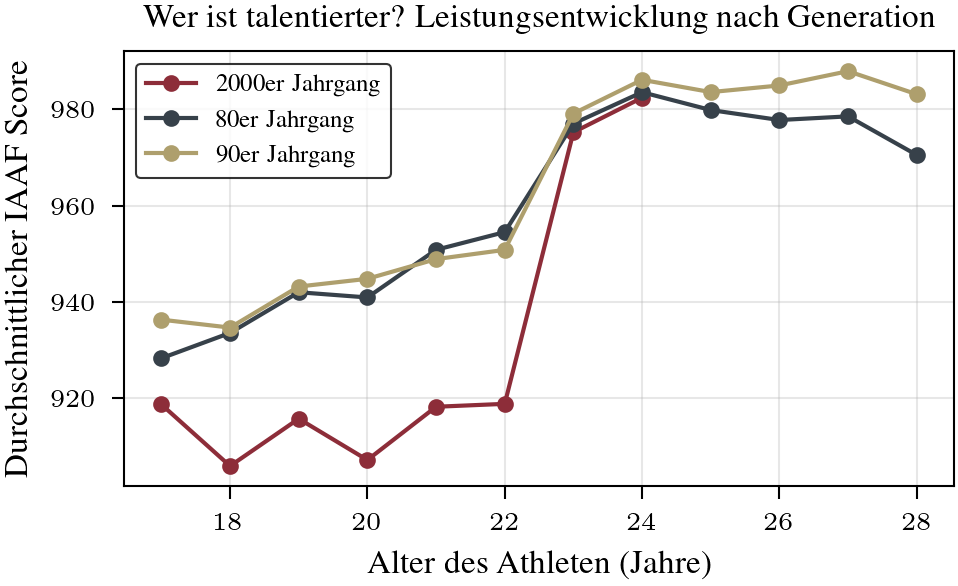

In [ ]:
# Wir bilden Kohorten basierend auf dem Geburtsjahrzehnt
# Funktion um Jahrgang in Jahrzehnt umzuwandeln (1993 -> "90er")
def get_cohort(year):
    if year < 1990: return "80er Jahrgang"
    if year < 2000: return "90er Jahrgang"
    if year < 2010: return "2000er Jahrgang"
    return "2010er Jahrgang"

df['kohorte'] = df['geburtsjahr'].apply(get_cohort)
df['alter'] = df['jahr'] - df['geburtsjahr']

# Wir gruppieren nach Kohorte und Alter (wir wollen wissen: Wie gut waren die mit 18, 19, 20...)
# Pivot Table: Zeilen=Alter, Spalten=Kohorte, Werte=Durchschnittsscore
cohort_analysis = df.groupby(['alter', 'kohorte'])['iaaf_score'].mean().unstack()

# Wir plotten nur das relevante Alter (z.B. 17 bis 28)
cohort_analysis = cohort_analysis.loc[17:28]

# plt.figure(figsize=(12, 6))

colors = {'80er Jahrgang': 'gray', '90er Jahrgang': 'blue', '2000er Jahrgang': 'orange'}

for column in cohort_analysis.columns:
    # Nur plotten, wenn Daten da sind
    if column in colors:
        plt.plot(cohort_analysis.index, cohort_analysis[column], 
                 marker='.', label=column)

plt.title('Wer ist talentierter? Leistungsentwicklung nach Generation')
plt.xlabel('Alter des Athleten (Jahre)')
plt.ylabel('Durchschnittlicher IAAF Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Text-Anmerkung für Data Literacy
# plt.text(18, 1000, "Vergleichbarkeit:\nSind die 2000er wirklich besser\noder sind die Schuhe besser?", 
#          bbox=dict(facecolor='white', alpha=0.8))

plt.show()

In [ ]:
print(df[df['jahr'] == 2019]['iaaf_score'].describe())
print(df[df['jahr'] == 2020]['iaaf_score'].describe())


count    3774.000000
mean      939.247483
std       138.848285
min         0.000000
25%       875.000000
50%       962.000000
75%      1023.000000
max      1284.000000
Name: iaaf_score, dtype: float64
count    3598.000000
mean      899.730128
std       157.291506
min         2.000000
25%       827.000000
50%       927.000000
75%      1000.000000
max      1355.000000
Name: iaaf_score, dtype: float64
